**ANOVA POST HOC**

Dataset loading

In [1]:
import pandas as pd
import scipy.stats as stats
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("iris")


Variables selection

In [2]:
groups = [
    df[df['species'] == 'setosa']['petal_length'],
    df[df['species'] == 'versicolor']['petal_length'],
    df[df['species'] == 'virginica']['petal_length']
]


Normality test

In [3]:
for g in groups:
    print(stats.shapiro(g))


ShapiroResult(statistic=np.float64(0.9549767850318988), pvalue=np.float64(0.0548114671955363))
ShapiroResult(statistic=np.float64(0.96600440254332), pvalue=np.float64(0.15847783815657573))
ShapiroResult(statistic=np.float64(0.9621864428612802), pvalue=np.float64(0.10977536903223506))


Homoscedasticity

In [4]:
stats.levene(groups[0], groups[1], groups[2])


LeveneResult(statistic=np.float64(19.480338801923573), pvalue=np.float64(3.1287566394085397e-08))

ANOVA

In [5]:
pg.anova(data=df, dv='petal_length', between='species')


,Source,ddof1,ddof2,F,p_unc,np2
0,species,2,147,1180.161182,2.856777e-91,0.941372


Tukey

In [6]:
pg.pairwise_tukey(data=df, dv='petal_length', between='species')


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,setosa,versicolor,1.462,4.260,-2.798,0.086067,-32.509597,2.153833e-14,-7.837941
1,setosa,virginica,1.462,5.552,-4.090,0.086067,-47.521176,2.153833e-14,-9.920532
2,versicolor,virginica,4.260,5.552,-1.292,0.086067,-15.011579,2.153833e-14,-2.501415


Plots

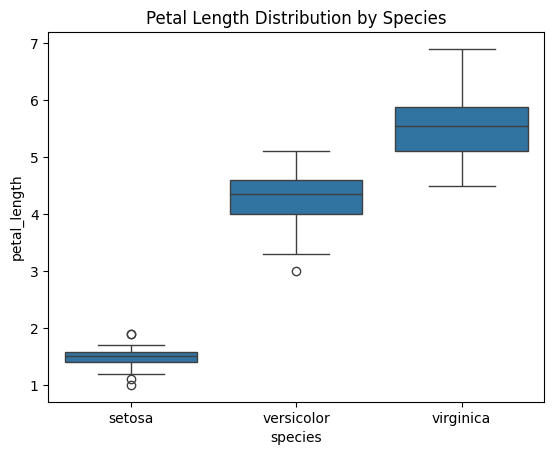

In [11]:
sns.boxplot(data=df, x='species', y='petal_length')
plt.title("Petal Length Distribution by Species")
plt.show()


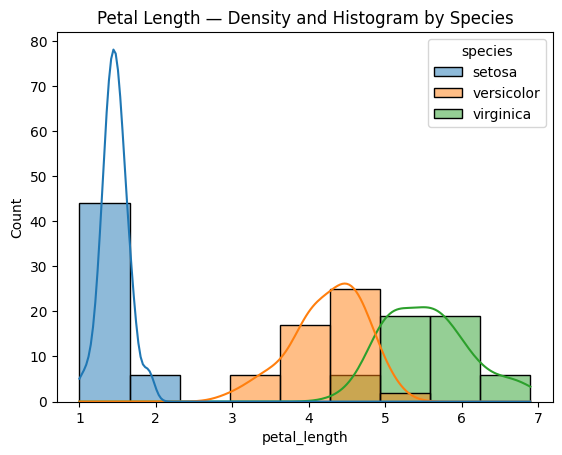

In [10]:
sns.histplot(data=df, x='petal_length', hue='species', kde=True)
plt.title("Petal Length — Density and Histogram by Species")
plt.show()
